# A notebook to explore the RNase experiment dataset (Taylor et al. 2018)

General statistics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel("/mnt/storage/ana01/data/elife-30094-supp1-v6_1.xlsx", sheet_name="RNAse")

color_counts = data['Color'].value_counts()
color_counts = color_counts.reindex(['pink', 'blue', 'gray', 'black'])

count_table = pd.DataFrame({
    "Category": color_counts.index,
    "Protein Count": color_counts.values
})



print("Protein count per category:\n", count_table.to_string(index=False))

avg_affinity = (
    data.groupby("Color")["Avg_affinity"]
    .mean()
)

affinity_table = pd.DataFrame({
    "Category": avg_affinity.index,
    "Average Affinity": avg_affinity.values
})

print("\nAverage Affinity per Category:\n", affinity_table.to_string(index=False))




Protein count per category:
 Category  Protein Count
    pink             15
    blue              7
    gray            122
   black              9

Average Affinity per Category:
 Category  Average Affinity
   black          0.481956
    blue          0.236643
    gray         -0.035560
    pink         -0.080947


Plots - pie chart of counts per color category

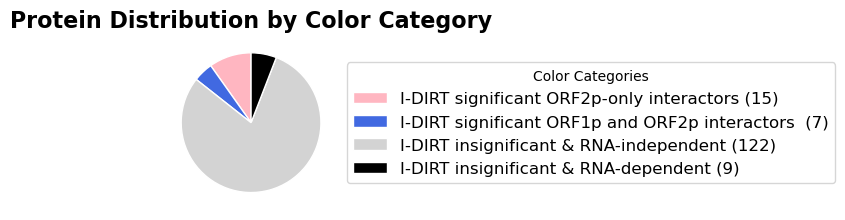

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

counts = color_counts.values


fig, ax = plt.subplots(figsize=(7, 7))

# Labels inside slices: counts + percentages
labels = [f"{count} ({count/sum(counts)*100:.1f}%)" for count in counts]

ax.pie(
    counts,
    labels=labels,
    colors=["lightpink", "royalblue", "lightgrey", "black"],
    autopct=None,  
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 12},
    startangle=90,  # optional, rotate chart for aesthetics
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Title
ax.set_title("Protein Distribution by Color Category", fontsize=16, weight='bold')

# Legend
legend_labels = [
    f"I-DIRT significant ORF2p-only interactors ({counts[0]})",
    f"I-DIRT significant ORF1p and ORF2p interactors  ({counts[1]})",
    f"I-DIRT insignificant & RNA-independent ({counts[2]})",
    f"I-DIRT insignificant & RNA-dependent ({counts[3]})"
]

ax.legend(
    legend_labels,
    title="Color Categories",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=12
)

plt.tight_layout()
plt.show()

Reproducing the raw data analysis and generating the two-dimentsional plot (Figure 3).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set style 
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

# distance from origin
data["distance"] = np.sqrt(
    data["Exp1_affinity"]**2 + data["Exp2_affinity"]**2
)

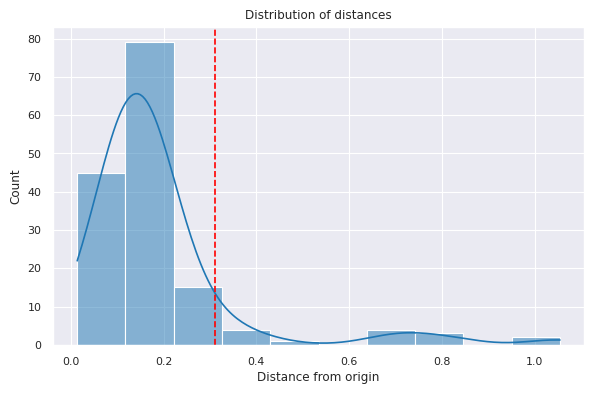

In [4]:
plt.figure(figsize=(6, 4))

sns.histplot(
    data["distance"],
    bins=10,
    kde=True
)

plt.xlabel("Distance from origin")
plt.ylabel("Count")
plt.title("Distribution of distances")

median_d = data["distance"].median()
plt.axvline(median_d*2, color="red", linestyle="--", label=f"Median: {median_d:.2f}")

plt.tight_layout()
plt.show()

In [5]:
median_d = data["distance"].median()

data_bg = data[data["distance"] < 2 * median_d].copy()

print(f"Total proteins: {len(data)}")
print(f"Background subset: {len(data_bg)}")

Total proteins: 153
Background subset: 138


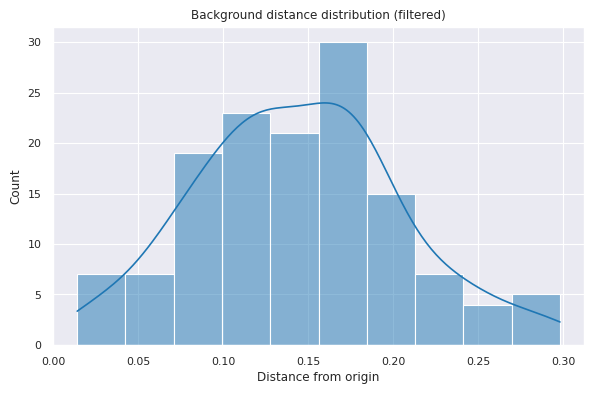

In [6]:
plt.figure(figsize=(6, 4))

sns.histplot(
    data_bg["distance"],
    bins=10,
    kde=True
)

plt.xlabel("Distance from origin")
plt.ylabel("Count")
plt.title("Background distance distribution (filtered)")

plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import shapiro

stat, p_value = shapiro(data_bg["distance"])

print(f"Shapiro-Wilk p-value (background): {p_value:.4f}")

Shapiro-Wilk p-value (background): 0.4168


In [8]:
from scipy.stats import norm

mu = data_bg["distance"].mean()
sigma = data_bg["distance"].std()

radius = norm.ppf(0.999, loc=mu, scale=sigma)
print(radius)

0.32958051661709414


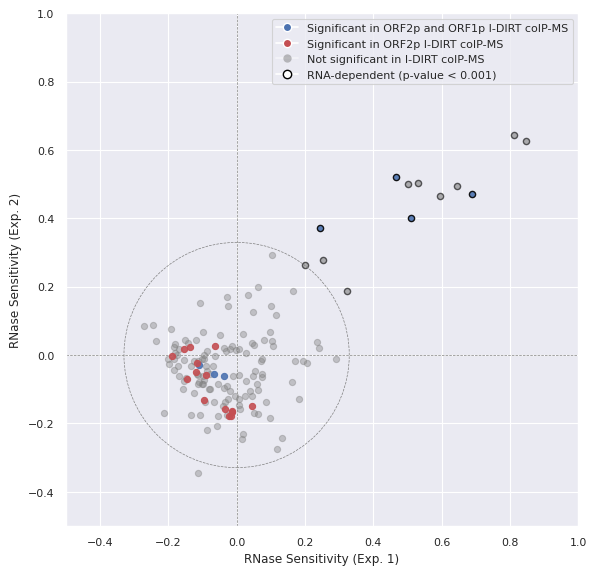

<Figure size 640x480 with 0 Axes>

In [10]:
# Color mapping (merge black into gray) 
palette = sns.color_palette("deep")

color_map = {
    "blue": palette[0],
    "pink": palette[3],
    "gray": "gray",
    "black": "gray"   # <- merge into gray
}

# Plot 
plt.figure(figsize=(6, 6))

# gray = one background group 
df_grey = data[data["Color"] == "gray"]

plt.scatter(
    df_grey["Exp1_affinity"],
    df_grey["Exp2_affinity"],
    c="gray",
    s=20,
    alpha=0.4,
    zorder=1
)

# black = grey dots with black outline
df_black = data[data["Color"] == "black"]

plt.scatter(
    df_black["Exp1_affinity"],
    df_black["Exp2_affinity"],
    c="gray",
    s=20,
    alpha=0.6,
    edgecolors="black",
    linewidths=1,
    zorder=1
)

# pink on top 
df_pink = data[data["Color"] == "pink"]
plt.scatter(
        df_pink["Exp1_affinity"],
        df_pink["Exp2_affinity"],
        c=[color_map["pink"]],
        s=20,
        alpha=0.9,
        zorder=3
    )

#split blue into RNase sensitive and insensitive
df_blue = data[data["Color"] == "blue"]
df_blue_insensitive = df_blue[df_blue["distance"] <= radius]
df_blue_sensitive = df_blue[df_blue["distance"] > radius]


plt.scatter(
        df_blue_insensitive["Exp1_affinity"],
        df_blue_insensitive["Exp2_affinity"],
        c=[color_map["blue"]],
        s=20,
        alpha=0.9,
        zorder=2
    )

plt.scatter(
        df_blue_sensitive["Exp1_affinity"],
        df_blue_sensitive["Exp2_affinity"],
        c=[color_map["blue"]],
        s=20,
        alpha=0.9,
        edgecolors="black",
        linewidths=1,
        zorder=2
    )


# Circle threshold 
circle = plt.Circle(
    (0, 0),
    radius,
    fill=False,
    linestyle="--",
    linewidth=0.5,
    color = "grey"
)
plt.gca().add_patch(circle)

# Labels & title
plt.xlabel("RNase Sensitivity (Exp. 1)")
plt.ylabel("RNase Sensitivity (Exp. 2)")


# Axes reference lines
plt.axhline(0, linestyle="--", linewidth=0.5, color = "gray")
plt.axvline(0, linestyle="--", linewidth=0.5, color = "gray")


# Equal scaling
plt.gca().set_aspect('equal', adjustable='box')

# Limits
plt.xlim(-0.5, 1)
plt.ylim(-0.5, 1)

# legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Significant in ORF2p and ORF1p I-DIRT coIP-MS',
           markerfacecolor=color_map["blue"], 
           markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label='Significant in ORF2p I-DIRT coIP-MS',
           markerfacecolor=color_map["pink"], 
           markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label='Not significant in I-DIRT coIP-MS',
           markerfacecolor='gray', markeredgecolor='none',
           alpha=0.5,
           markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label='RNA-dependent (p-value < 0.001)',
           markerfacecolor='white',
           markeredgecolor='black',
           markersize=6)
]

plt.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()
plt.savefig("/mnt/storage/ana01/results/thesis_figures/RNAse_sensitivity_scatter_plot.png", dpi=300)

Defining identities of proteins for positive and negative analysis subsets

In [11]:
pink= data[data["Color"]=="pink"]
cols_to_keep = ["Genes", "Uniprot", "Protein"]
pink_names = pink[cols_to_keep].copy()

pink_names["cpIP_MS_significance"] = "ORF2"
pink_names["Analysis_category"] = "+"

pink_names = pink_names.reset_index(drop=True)
pink_names

,Genes,Uniprot,Protein,cpIP_MS_significance,Analysis_category
0,FKBP4,Q02790,Peptidyl-prolyl cis-trans isomerase FKBP4,ORF2,+
1,HAX1,O00165,HCLS1-associated protein X-1,ORF2,+
2,PURB,Q96QR8,Transcriptional activator protein Pur-beta,ORF2,+
3,IPO7,O95373,Importin-7,ORF2,+
4,TUBB,P07437,Tubulin beta chain,ORF2,+
5,HSP90AA1,P07900,Heat shock protein HSP 90-alpha,ORF2,+
6,HSP90AB1,P08238,Heat shock protein HSP 90-beta,ORF2,+
7,PARP1,P09874,Poly [ADP-ribose] polymerase 1,ORF2,+
8,"HSPA1A, HSPA1B","P0DMV8, P0DMV9","Heat shock 70 kDa protein 1A, Heat shock 70 kD...",ORF2,+
9,HSPA8,P11142,Heat shock cognate 71 kDa protein,ORF2,+


In [12]:
blue= data[data["Color"]=="blue"]
cols_to_keep = ["Genes", "Uniprot", "Protein"]
blue_names = blue[cols_to_keep].copy()

blue_names["cpIP_MS_significance"] = "ORF1/2"
blue_names["Analysis_category"] = "-"

for name in ["PABPC4", "PABPC1", "ORF2"]:
    blue_names.loc[blue_names["Genes"] == name, "Analysis_category"] = "+"

blue_names = blue_names.sort_values(
    by="Analysis_category",
    ascending=True
).reset_index(drop=True)

blue_names

,Genes,Uniprot,Protein,cpIP_MS_significance,Analysis_category
0,PABPC4,Q13310,Polyadenylate-binding protein 4,ORF1/2,+
1,PABPC1,P11940,Polyadenylate-binding protein 1,ORF1/2,+
2,ORF2,O00370,NaN,ORF1/2,+
3,L1RE (ORF1),Q9UN81,LINE-1 retrotransposable element ORF1 protein,ORF1/2,-
4,MOV10,Q9HCE1,Putative helicase MOV-10,ORF1/2,-
5,ZCCHC3,Q9NUD5,Zinc finger CCHC domain-containing protein 3,ORF1/2,-
6,UPF1,Q92900,Regulator of nonsense transcripts 1,ORF1/2,-


In [13]:
black= data[data["Color"]=="black"]
cols_to_keep = ["Genes", "Uniprot", "Protein"]
black_names = black[cols_to_keep].copy()

black_names["cpIP_MS_significance"] = "None"
black_names["Analysis_category"] = "-"

black_names = black_names.reset_index(drop=True)



#black_names.to_excel("/mnt/storage/ana01/results/thesis_figures/RNAse_sensitivity_black_proteins_indentity.xlsx", index=False)
black_names


,Genes,Uniprot,Protein,cpIP_MS_significance,Analysis_category
0,RPL10A,P62906,60S ribosomal protein L10a,None,-
1,RPL12,P30050,60S ribosomal protein L12,None,-
2,RBM8A,Q9Y5S9,RNA-binding protein 8A,None,-
3,"RPLP0, RPLP0P6","P05388, Q8NHW5","60S acidic ribosomal protein P0, 60S acidic ri...",None,-
4,EIF4A3,P38919,Eukaryotic initiation factor 4A-III,None,-
5,MAGOH,P61326,Protein mago nashi homolog,None,-
6,SRSF7,Q16629,Serine/arginine-rich splicing factor 7,None,-
7,RPL30,P62888,60S ribosomal protein L30,None,-
8,TRA2A,Q13595,Transformer-2 protein homolog alpha,None,-


In [14]:
final_df=pd.concat([pink_names, blue_names, black_names], axis = 0, ignore_index=True)

final_df.to_excel("/mnt/storage/ana01/results/thesis_figures/RNAse_sensitivity_full_protein_list.xlsx", index=False)